In [84]:
from __future__ import annotations

import operator
import re
import json
from pathlib import Path
from typing import TypedDict, List, Optional, Literal, Annotated
from pydantic import BaseModel, Field, field_validator, ConfigDict

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.output_parsers import PydanticOutputParser
from langchain_community.tools.tavily_search import TavilySearchResults


In [85]:

# -----------------------------
# Helper: Cleaning Llama JSON Outputs
# -----------------------------
def parse_llm_json(response_content: str, parser: PydanticOutputParser):
    """Clean markdown code fences from LLM responses before parsing with Pydantic."""
    cleaned = response_content.strip()
    if cleaned.startswith("```"):
        cleaned = re.sub(r"^```(?:json)?\s*", "", cleaned)
        cleaned = re.sub(r"\s*```$", "", cleaned)
    return parser.parse(cleaned)


In [86]:
# -----------------------------
# 1) Schemas
# -----------------------------
class Task(BaseModel):
    model_config = ConfigDict(extra="ignore")
    
    id: int
    title: str
    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        min_length=1,
        max_length=6,
        description="1–6 concrete subpoints to cover in this section.",
    )
    target_words: int = Field(..., description="Target word count for this section (120–550).")
    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False

class Plan(BaseModel):
    model_config = ConfigDict(extra="ignore")
    
    blog_title: str
    audience: str
    tone: str
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]

class EvidenceItem(BaseModel):
    model_config = ConfigDict(extra="ignore")
    
    title: str
    url: str
    published_at: Optional[str] = None
    snippet: Optional[str] = None
    source: Optional[str] = None

class RouterDecision(BaseModel):
    model_config = ConfigDict(extra="ignore")
    
    needs_research: bool = Field(
        ..., 
        description="Must be a JSON boolean: true or false."
    )
    mode: Literal["closed_book", "hybrid", "open_book"]
    queries: List[str] = Field(default_factory=list)

    @field_validator("needs_research", mode="before")
    @classmethod
    def parse_bool_string(cls, v):
        if isinstance(v, str):
            return v.lower() in ("true", "1", "yes")
        return v

class EvidencePack(BaseModel):
    model_config = ConfigDict(extra="ignore")
    evidence: List[EvidenceItem] = Field(default_factory=list)

class State(TypedDict):
    topic: str
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]
    sections: Annotated[List[tuple[int, str]], operator.add]
    final: str

In [ ]:


# -----------------------------
# 2) LLM Init (JSON Mode Forced)
# -----------------------------
llm = ChatGroq(
    model="llama-3.1-8b-instant", 
    temperature=0.1,
    model_kwargs={"response_format": {"type": "json_object"}}
)

In [ ]:

# for Text generation plain model 
llm_text = ChatGroq(model="llama-3.1-8b-instant", temperature=0.3)


In [89]:

# -----------------------------
# 3) Router Node
# -----------------------------
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.
Decide whether web research is needed BEFORE planning.
Modes:
- closed_book (needs_research=false): Evergreen topics.
- hybrid (needs_research=true): Up-to-date examples needed.
- open_book (needs_research=true): Volatile/news topics.
If needs_research=true, output 3–10 high-signal specific queries.

{format_instructions}"""

def router_node(state: State) -> dict:
    parser = PydanticOutputParser(pydantic_object=RouterDecision)
    sys_prompt = ROUTER_SYSTEM.format(format_instructions=parser.get_format_instructions())
    
    res = llm.invoke(
        [
            SystemMessage(content=sys_prompt),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    decision = parse_llm_json(res.content, parser)
    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
    }

def route_next(state: State) -> str:
    return "research" if state["needs_research"] else "orchestrator"

# -----------------------------
# 4) Research Node
# -----------------------------
def _tavily_search(query: str, max_results: int = 5) -> List[dict]:
    tool = TavilySearchResults(max_results=max_results)
    try:
        results = tool.invoke({"query": query})
    except Exception:
        results = []

    normalized: List[dict] = []
    for r in results or []:
        if isinstance(r, dict):
            normalized.append(
                {
                    "title": r.get("title") or "",
                    "url": r.get("url") or "",
                    "snippet": r.get("content") or r.get("snippet") or "",
                    "published_at": r.get("published_date") or r.get("published_at"),
                    "source": r.get("source"),
                }
            )
    return normalized

RESEARCH_SYSTEM = """You are a research synthesizer. Produce a deduplicated list of EvidenceItem objects.
{format_instructions}"""

def research_node(state: State) -> dict:
    queries = (state.get("queries", []) or [])[:10]
    raw_results: List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=5))

    if not raw_results:
        return {"evidence": []}

    parser = PydanticOutputParser(pydantic_object=EvidencePack)
    sys_prompt = RESEARCH_SYSTEM.format(format_instructions=parser.get_format_instructions())

    res = llm.invoke(
        [
            SystemMessage(content=sys_prompt),
            HumanMessage(content=f"Raw results:\n{raw_results}"),
        ]
    )
    pack = parse_llm_json(res.content, parser)

    dedup = {}
    for e in (pack.evidence or []):
        if e.url:
            dedup[e.url] = e

    return {"evidence": list(dedup.values())}

In [90]:
# -----------------------------
# 5) Orchestrator Node
# -----------------------------
ORCH_SYSTEM = """You are a senior technical writer. Produce a 5-9 task outline matching the required schema.

Requirements:
- Output strictly valid JSON matching the format instructions.
- Ensure 'tasks' is a clean array of Task objects.

{format_instructions}"""

def orchestrator_node(state: State) -> dict:
    parser = PydanticOutputParser(pydantic_object=Plan)
    sys_prompt = ORCH_SYSTEM.format(format_instructions=parser.get_format_instructions())
    
    evidence = state.get("evidence", [])
    mode = state.get("mode", "closed_book")
    evidence_dumps = [e.model_dump() if hasattr(e, 'model_dump') else e for e in evidence]

    res = llm.invoke(
        [
            SystemMessage(content=sys_prompt),
            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n\n"
                    f"Evidence:\n{evidence_dumps[:16]}"
                )
            ),
        ]
    )
    plan = parse_llm_json(res.content, parser)
    return {"plan": plan}


In [91]:
# -----------------------------
# 6) Fanout Edge
# -----------------------------
def fanout(state: State):
    evidence_dumps = [
        e.model_dump() if hasattr(e, 'model_dump') else e 
        for e in state.get("evidence", [])
    ]
    return [
        Send(
            "worker",
            {
                "task": task.model_dump(),
                "topic": state["topic"],
                "mode": state["mode"],
                "plan": state["plan"].model_dump(),
                "evidence": evidence_dumps,
            },
        )
        for task in state["plan"].tasks
    ]

In [ ]:
# -----------------------------
# 7) Worker Node (Markdown Generation Uses Plain Text LLM)
# -----------------------------
WORKER_SYSTEM = """You are a senior technical writer. Write ONE section of a blog post in Markdown starting with '## <Section Title>'."""

def worker_node(payload: dict) -> dict:
    task = Task(**payload["task"])
    plan = Plan(**payload["plan"])
    
    raw_ev = payload.get("evidence", [])
    evidence = [e if isinstance(e, EvidenceItem) else EvidenceItem(**e) for e in raw_ev]

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    evidence_text = ""
    if evidence:
        evidence_text = "\n".join(
            f"- Title: {e.title} | URL: {e.url}\n  Snippet: {e.snippet or 'N/A'}"
            for e in evidence[:20]
        )

    # Note: Text section generation ke liye `llm_text` use kar rahe hain taaki pure Markdown mile, JSON nahi.
    section_md = llm_text.invoke(
        [
            SystemMessage(content=WORKER_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Requires Citations: {task.requires_citations}\n"
                    f"Requires Code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence:\n{evidence_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [(task.id, section_md)]}

In [93]:
# -----------------------------
# 8) Reducer Node
# -----------------------------
def reducer_node(state: State) -> dict:
    plan = state["plan"]
    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    final_md = f"# {plan.blog_title}\n\n{body}\n"

    safe_title = re.sub(r'[^\w\s-]', '', plan.blog_title).strip().replace(' ', '_')
    filename = f"{safe_title}.md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [94]:
# -----------------------------
# 9) Build Graph & Compile
# -----------------------------
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_node)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

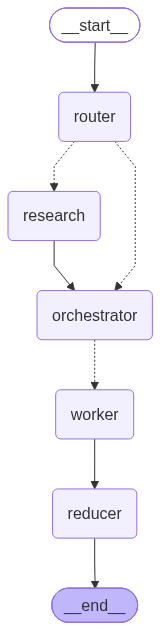

In [95]:
app

In [96]:
# -----------------------------
# 10) Runner
# -----------------------------
def run(topic: str) -> str:
    final_state = app.invoke(
        {
            "topic": topic,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "sections": [],
            "final": "",
        }
    )
    if final_state.get("plan"):
        safe_title = re.sub(r'[^\w\s-]', '', final_state["plan"].blog_title).strip().replace(' ', '_')
        print(f"\n[SUCCESS] Blog Post saved to: {safe_title}.md")
        
    return final_state.get("final", "")

In [83]:
run("State of Multimodal LLMs in 2026")


[SUCCESS] Blog Post saved to: State_of_Multimodal_LLMs_in_2026.md


"# State of Multimodal LLMs in 2026\n\n## Overview of Multimodal LLMs\n\nMultimodal Large Language Models (LLMs) have gained significant attention in recent years due to their ability to process and understand multiple forms of data, such as text, images, and audio. In this section, we will provide an overview of multimodal LLMs, their types, advantages, limitations, and current applications in Natural Language Processing (NLP).\n\n### Definition and Types of Multimodal LLMs\n\nMultimodal LLMs are a type of deep learning model that can process and integrate multiple modalities of data, such as text, images, and audio (Huang et al., 2020). There are several types of multimodal LLMs, including:\n\n* **Visual-Linguistic Models**: These models process text and images simultaneously, allowing for tasks such as image captioning and visual question answering (VQA) (Lu et al., 2019).\n* **Audio-Text Models**: These models process audio and text data, enabling tasks such as speech recognition a